In [1]:
# === Held-out evaluation for latest v3 run (macro/micro Dice, CSV+JSON) ===
from pathlib import Path
import importlib.util, json, time
import numpy as np

# --------- Paths (v3 run + held-out set) ----------
RUN_DIR   = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20260410_174944")
TEST_DIR  = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/A_A_Combined_Data/Processed_HiresLowres_Split_Data/test_hires")
T1_DIR    = TEST_DIR / "t1"      # use these to avoid duplicate pairing
MSK_DIR   = TEST_DIR / "masks"
TRAIN_MOD = Path("/home/rbielski/stroke_cleaned/stroke_segmentation_v1.2/stroke_seg_v1.2_train.py")
# -----------------------------------------------

# ---- Import training module (utils + custom layers) ----
spec = importlib.util.spec_from_file_location("arc_seg_train", TRAIN_MOD)
seg = importlib.util.module_from_spec(spec)
spec.loader.exec_module(seg)

# ---- Find model to load (prefer full .keras; else rebuild and load weights) ----
models_dir     = RUN_DIR / "models"
callbacks_dir  = RUN_DIR / "callbacks"
full_models    = sorted(models_dir.glob("*.keras"))
best_weights   = callbacks_dir / "best_model_dynamic.weights.h5"
cfg_json_path  = models_dir / "config.json"  # written by training code

model = None
INPUT_SHAPE = None

custom_objects = {
    "ResidualConvBlock": seg.ResidualConvBlock,
    "VisionMambaBlock": seg.VisionMambaBlock,
    "SAM2Attention": seg.SAM2Attention,
    "CombinedLoss": seg.CombinedLoss,
    "dice_coefficient": seg.dice_coefficient,
    "dice_loss": seg.dice_loss,
    "boundary_loss": seg.boundary_loss,
}

try:
    from keras.saving import load_model as keras_load_model
except Exception:
    from tensorflow.keras.models import load_model as keras_load_model

if full_models:
    model_path = full_models[-1]
    print(f"Loading FULL model: {model_path}")
    model = keras_load_model(model_path, compile=False, custom_objects=custom_objects)
    INPUT_SHAPE = tuple(model.input_shape[1:])
else:
    assert cfg_json_path.exists(), f"Missing {cfg_json_path}"
    with open(cfg_json_path) as f:
        saved_cfg = json.load(f)
    cfg = seg.DynamicTrainingConfig(
        DATA_DIR=TEST_DIR,  # dummy; not training now
        MODEL_DIR=models_dir,
        CALLBACKS_DIR=callbacks_dir,
        INPUT_SHAPE=tuple(saved_cfg["INPUT_SHAPE"]) if saved_cfg.get("INPUT_SHAPE") else None,
        BASE_FILTERS=int(saved_cfg.get("BASE_FILTERS", 8)),
        SAM_HEADS=int(saved_cfg.get("SAM_HEADS", 2)),
    )
    if cfg.INPUT_SHAPE in (None, (), []):
        raise RuntimeError("INPUT_SHAPE missing in saved config; cannot rebuild model.")
    INPUT_SHAPE = cfg.INPUT_SHAPE
    print("Rebuilding model from config.json and loading best weights…")
    model = seg.build_dynamic_model(cfg)
    model.load_weights(str(best_weights))

print("INPUT_SHAPE:", INPUT_SHAPE)

# ---- Build held-out list using separated subfolders (avoid duplicates) ----
if T1_DIR.exists() and MSK_DIR.exists():
    cfg_eval = seg.DynamicTrainingConfig(DATA_DIR=TEST_DIR, IMAGES_DIR=T1_DIR, MASKS_DIR=MSK_DIR,
                                         MODEL_DIR=RUN_DIR/"_tmp_models", CALLBACKS_DIR=RUN_DIR/"_tmp_callbacks")
else:
    cfg_eval = seg.DynamicTrainingConfig(DATA_DIR=TEST_DIR,
                                         MODEL_DIR=RUN_DIR/"_tmp_models", CALLBACKS_DIR=RUN_DIR/"_tmp_callbacks")

cfg_eval.INPUT_SHAPE = INPUT_SHAPE
pairs, lesion_presence = seg.load_generic_dataset(cfg_eval)
print(f"Pairs: {len(pairs)} | % non-empty masks: {lesion_presence.mean()*100:.1f}%")

# ---- Dice helpers ----
def dice_soft(y, p):
    y = y.astype(np.float64); p = p.astype(np.float64)
    inter = (y * p).sum()
    return (2.0*inter) / (y.sum() + p.sum() + 1e-12)

def dice_hard(y, p, th=0.5):
    pb = (p >= th).astype(np.float64)
    inter = (y*pb).sum()
    return (2.0*inter) / (y.sum() + pb.sum() + 1e-12)

# ---- Evaluate (macro: per-case mean; micro: global) ----
macro_softs, macro_hards = [], []
s_inter_soft = np.float64(0.0)
s_sumy_soft  = np.float64(0.0)
s_sump_soft  = np.float64(0.0)

TH = 0.50  # default; you can sweep later

for i, (img_p, msk_p) in enumerate(pairs, 1):
    img = seg._load_and_preprocess_image(str(img_p), INPUT_SHAPE[:-1]).astype(np.float32)
    y   = seg._load_and_preprocess_mask(str(msk_p),  INPUT_SHAPE[:-1]).astype(np.float32)

    x = np.zeros((1,*INPUT_SHAPE), np.float32)
    x[0,...,0] = img
    p = model.predict(x, verbose=0)[0,...,0].astype(np.float32)

    ds = dice_soft(y, p)
    dh = dice_hard(y, p, th=TH)
    macro_softs.append(ds); macro_hards.append(dh)

    s_inter_soft += (y.astype(np.float64) * p.astype(np.float64)).sum()
    s_sumy_soft  += y.sum(dtype=np.float64)
    s_sump_soft  += p.sum(dtype=np.float64)

    if i % 10 == 0 or i == len(pairs):
        print(f"[{i}/{len(pairs)}] last case soft={ds:.4f} hard@{TH:.2f}={dh:.4f}")

macro_soft = float(np.mean(macro_softs))
macro_hard = float(np.mean(macro_hards))
micro_soft = float((2.0*s_inter_soft) / (s_sumy_soft + s_sump_soft + 1e-12))

# A second pass for exact micro-hard at the same threshold (memory-safe)
s_inter_hard = np.float64(0.0)
s_sumy_hard  = np.float64(0.0)
s_sump_hard  = np.float64(0.0)
for img_p, msk_p in pairs:
    y = seg._load_and_preprocess_mask(str(msk_p), INPUT_SHAPE[:-1]).astype(np.float32)
    x = np.zeros((1,*INPUT_SHAPE), np.float32)
    x[0,...,0] = seg._load_and_preprocess_image(str(img_p), INPUT_SHAPE[:-1]).astype(np.float32)
    p = model.predict(x, verbose=0)[0,...,0]
    pb = (p >= TH).astype(np.float64)
    s_inter_hard += (y.astype(np.float64) * pb).sum()
    s_sumy_hard  += y.sum(dtype=np.float64)
    s_sump_hard  += pb.sum(dtype=np.float64)

micro_hard = float((2.0*s_inter_hard) / (s_sumy_hard + s_sump_hard + 1e-12))

# ---- Report + save ----
print("\n=== HELD-OUT RESULTS ===")
print(f"Per-case (macro) soft Dice       : {macro_soft:.4f}")
print(f"Per-case (macro) hard Dice @ {TH:.2f}: {macro_hard:.4f}")
print(f"Global (micro) soft Dice         : {micro_soft:.4f}")
print(f"Global (micro) hard Dice @ {TH:.2f} : {micro_hard:.4f}")
print(f"Val set size: {len(pairs)} cases")

out_dir = RUN_DIR / "test_eval"
out_dir.mkdir(parents=True, exist_ok=True)
ts = time.strftime("%Y%m%d_%H%M%S")

# per-case CSV
csv_path = out_dir / f"test_metrics_{ts}.csv"
with open(csv_path, "w") as f:
    f.write("case,soft_dice,hard_dice_at_{:.2f}\n".format(TH))
    for (img_p, _), ds, dh in zip(pairs, macro_softs, macro_hards):
        f.write(f"{img_p.stem},{ds:.6f},{dh:.6f}\n")

# summary JSON
summary = {
    "threshold": TH,
    "macro_soft": macro_soft,
    "macro_hard": macro_hard,
    "micro_soft": micro_soft,
    "micro_hard": micro_hard,
    "n_cases": len(pairs),
    "run_dir": str(RUN_DIR),
}
json_path = out_dir / f"test_metrics_summary_{ts}.json"
with open(json_path, "w") as f:
    json.dump(summary, f, indent=2)

print("\nWrote per-case CSV ->", csv_path)
print("Wrote summary JSON ->", json_path)


2026-04-13 10:53:01.602328: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Visible GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')


I0000 00:00:1776099183.597818 2290215 gpu_process_state.cc:208] Using CUDA malloc Async allocator for GPU: 0
I0000 00:00:1776099183.598981 2290215 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3181 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:41:00.0, compute capability: 8.9
I0000 00:00:1776099183.599265 2290215 gpu_process_state.cc:208] Using CUDA malloc Async allocator for GPU: 1
I0000 00:00:1776099183.600259 2290215 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13769 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:61:00.0, compute capability: 8.9
2026-04-13 10:53:03,674 - SmartSOTA_Dynamic - INFO - ✅ All imports successful
2026-04-13 10:53:03,674 - SmartSOTA_Dynamic - INFO - TensorFlow eager execution: True
2026-04-13 10:53:03,675 - SmartSOTA_Dynamic - INFO - Environment verified:
- Python 3.10.18 (main, Jun  5 2025, 13:14:17) [GCC 11.2.0]
- TensorFlow

Strategy: MirroredStrategy
Loading FULL model: /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20260410_174944/models/smart_sota_dynamic_20260410_174944.keras


2026-04-13 10:53:05,008 - SmartSOTA_Dynamic - INFO - 📚 Loading dataset (flex loader for T1w volumes)…
2026-04-13 10:53:05,009 - SmartSOTA_Dynamic - INFO - Memory at dataset_load_start: CPU=1.05GB | GPU mem tracking failed | Disk: 491.2GB free
2026-04-13 10:53:05,011 - SmartSOTA_Dynamic - INFO - 📂 Two-folder mode: images=138 (/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/A_A_Combined_Data/Processed_HiresLowres_Split_Data/test_hires/t1), masks=138 (/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/A_A_Combined_Data/Processed_HiresLowres_Split_Data/test_hires/masks)
2026-04-13 10:53:05,012 - SmartSOTA_Dynamic - INFO - Found 138 image files and 138 mask files


INPUT_SHAPE: (192, 224, 192, 1)


2026-04-13 10:53:36,706 - SmartSOTA_Dynamic - INFO - 📊 Created 138 image–mask pairs
2026-04-13 10:53:36,707 - SmartSOTA_Dynamic - INFO - 🧠 Lesion presence: 100.00%
2026-04-13 10:53:36,709 - SmartSOTA_Dynamic - INFO - Memory at dataset_load_end: CPU=1.06GB | GPU mem tracking failed | Disk: 491.2GB free


Pairs: 138 | % non-empty masks: 100.0%


2026-04-13 10:53:37.905293: I external/local_xla/xla/service/service.cc:163] XLA service 0x77c00c00b250 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-13 10:53:37.905320: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2026-04-13 10:53:37.905327: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (1): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2026-04-13 10:53:37.976497: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-13 10:53:38.263897: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91001
2026-04-13 10:53:40.057737: E external/local_xla/xla/stream_executor/gpu/gpu_cudamallocasync_allocator.cc:361] gpu_async_0 cuMemAllocAsync failed to allocate 4773648048 bytes: RESOURCE_EXHAUSTED: :

[10/138] last case soft=0.8368 hard@0.50=0.8373
[20/138] last case soft=0.8574 hard@0.50=0.8571
[30/138] last case soft=0.8205 hard@0.50=0.8209
[40/138] last case soft=0.5289 hard@0.50=0.5291
[50/138] last case soft=0.7456 hard@0.50=0.7461
[60/138] last case soft=0.7953 hard@0.50=0.7956
[70/138] last case soft=0.8078 hard@0.50=0.8080
[80/138] last case soft=0.3782 hard@0.50=0.3787
[90/138] last case soft=0.7460 hard@0.50=0.7464
[100/138] last case soft=0.0691 hard@0.50=0.0699
[110/138] last case soft=0.6636 hard@0.50=0.6659
[120/138] last case soft=0.5556 hard@0.50=0.5569
[130/138] last case soft=0.4822 hard@0.50=0.4831
[138/138] last case soft=0.0288 hard@0.50=0.0287

=== HELD-OUT RESULTS ===
Per-case (macro) soft Dice       : 0.5619
Per-case (macro) hard Dice @ 0.50: 0.5623
Global (micro) soft Dice         : 0.7191
Global (micro) hard Dice @ 0.50 : 0.7193
Val set size: 138 cases

Wrote per-case CSV -> /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20260410_1

In [2]:
# === Interactive MRI viewer for v3 held-out eval (uses saved preds *or* computes on-the-fly) ===
# CONFIG — set these two:
RUN_DIR  = "/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20260410_174944"
TEST_DIR = "/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/A_A_Combined_Data/Processed_HiresLowres_Split_Data/test_hires"

# Optional: if you already saved NIfTI preds, point here; else leave "" to compute on-the-fly.
PREDS_DIR = ""   # e.g. "/.../test_preds_t050"

# -----------------------------------------------------------------------------------------------
import os, re, glob, numpy as np, nibabel as nib, matplotlib.pyplot as plt, importlib.util, time, json, pathlib
from ipywidgets import Dropdown, IntSlider, FloatSlider, RadioButtons, Checkbox, Button, HBox, VBox, Layout, HTML, Output
from IPython.display import display

RUN_DIR   = pathlib.Path(RUN_DIR)
TEST_DIR  = pathlib.Path(TEST_DIR)
T1_DIR    = TEST_DIR / "t1"
MSK_DIR   = TEST_DIR / "masks"
PREDS_DIR = pathlib.Path(PREDS_DIR) if PREDS_DIR else None

# ---- load training module & model (for on-the-fly mode) ----
def _load_seg_module():
    TRAIN_MOD = "/home/rbielski/stroke_cleaned/stroke_segmentation_v1.2/stroke_seg_v1.2_train.py"
    spec = importlib.util.spec_from_file_location("arc_seg_train", TRAIN_MOD)
    seg  = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(seg)
    return seg

def _load_model_if_needed():
    if PREDS_DIR and PREDS_DIR.exists():
        return None, None  # using precomputed NIfTIs; no model needed
    # load full .keras if present else rebuild from config.json + best weights
    seg = _load_seg_module()
    models_dir    = RUN_DIR / "models"
    callbacks_dir = RUN_DIR / "callbacks"
    full_models   = sorted(models_dir.glob("*.keras"))
    custom_objects = {
        "ResidualConvBlock": seg.ResidualConvBlock,
        "VisionMambaBlock": seg.VisionMambaBlock,
        "SAM2Attention": seg.SAM2Attention,
        "CombinedLoss": seg.CombinedLoss,
        "dice_coefficient": seg.dice_coefficient,
        "dice_loss": seg.dice_loss,
        "boundary_loss": seg.boundary_loss,
    }
    try:
        from keras.saving import load_model as keras_load_model
    except Exception:
        from tensorflow.keras.models import load_model as keras_load_model

    if full_models:
        m = keras_load_model(full_models[-1], compile=False, custom_objects=custom_objects)
        input_shape = tuple(m.input_shape[1:])
        return (seg, (m, input_shape))
    # fallback rebuild
    cfg_json = models_dir / "config.json"
    assert cfg_json.exists(), f"Missing {cfg_json}"
    with open(cfg_json) as f: saved_cfg = json.load(f)
    cfg = seg.DynamicTrainingConfig(
        DATA_DIR=TEST_DIR, MODEL_DIR=models_dir, CALLBACKS_DIR=callbacks_dir,
        INPUT_SHAPE=tuple(saved_cfg["INPUT_SHAPE"]) if saved_cfg.get("INPUT_SHAPE") else None,
        BASE_FILTERS=int(saved_cfg.get("BASE_FILTERS", 8)),
        SAM_HEADS=int(saved_cfg.get("SAM_HEADS", 2)),
    )
    assert cfg.INPUT_SHAPE, "INPUT_SHAPE missing in saved config; cannot rebuild"
    m = seg.build_dynamic_model(cfg)
    m.load_weights(str(callbacks_dir / "best_model_dynamic.weights.h5"))
    return (seg, (m, cfg.INPUT_SHAPE))

# ---- file matching helpers ----
def _norm_key(name: str) -> str:
    n = re.sub(r"\.nii(\.gz)?$", "", name)
    n = re.sub(r"_T1w", "", n)
    n = re.sub(r"_lesion_mask(_MNI)?_clean", "", n)
    n = re.sub(r"_MNI_norm", "", n)
    n = re.sub(r"_(soft|hard)$", "", n)
    return n

def _rglob(patterns, root):
    out = []
    for p in patterns:
        out.extend(glob.glob(os.path.join(str(root), "**", p), recursive=True))
    return sorted(out)

def _gather_gt_t1(test_dir):
    gt_map  = {_norm_key(os.path.basename(p)): p for p in _rglob(["*lesion_mask*.nii.gz"], test_dir)}
    mri_map = {_norm_key(os.path.basename(p)): p for p in _rglob(["*T1w*.nii.gz"], test_dir)}
    return gt_map, mri_map

def _gather_preds(preds_root):
    soft = _rglob(["*_soft.nii.gz"], preds_root)
    hard = _rglob(["*_hard.nii.gz"], preds_root)
    return ({_norm_key(os.path.basename(p)): p for p in soft},
            {_norm_key(os.path.basename(p)): p for p in hard})

# ---- build case list (supports: precomputed preds or on-the-fly) ----
seg_mod, model_bundle = _load_model_if_needed()
gt_map, mri_map = _gather_gt_t1(TEST_DIR)

if PREDS_DIR and PREDS_DIR.exists():
    psoft_map, phard_map = _gather_preds(PREDS_DIR)
    keys = sorted(set(psoft_map) & set(gt_map) & set(mri_map))
    cases = [{
        "key": k, "mri": mri_map[k], "gt": gt_map[k],
        "pred_soft": psoft_map[k], "pred_hard": phard_map.get(k)  # may be None
    } for k in keys]
else:
    # on-the-fly prediction cache
    CACHE_DIR = RUN_DIR / "test_view_cache"
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    psoft_map, phard_map = {}, {}
    keys = sorted(set(gt_map) & set(mri_map))
    cases = [{
        "key": k, "mri": mri_map[k], "gt": gt_map[k],
        "pred_soft": str(CACHE_DIR / f"{k}_soft.nii.gz"),
        "pred_hard": None
    } for k in keys]

if not cases:
    raise RuntimeError("No matching cases. Check TEST_DIR (and PREDS_DIR if set).")

# ---- lazy loaders / cache ----
_cache = {}
def _ensure_pred(case):
    """If on-the-fly mode, materialize *_soft.nii.gz to cache."""
    if PREDS_DIR and PREDS_DIR.exists():
        return  # already have files
    assert seg_mod is not None and model_bundle is not None, "Model not loaded"
    m, INPUT_SHAPE = model_bundle
    soft_path = pathlib.Path(case["pred_soft"])
    if soft_path.exists():
        return
    # compute prediction
    img = seg_mod._load_and_preprocess_image(case["mri"], INPUT_SHAPE[:-1]).astype(np.float32)
    x = np.zeros((1,*INPUT_SHAPE), np.float32); x[0,...,0] = img
    p = m.predict(x, verbose=0)[0,...,0].astype(np.float32)
    # write NIfTI aligned to MRI
    affine = nib.load(case["mri"]).affine
    nib.save(nib.Nifti1Image(p, affine), str(soft_path))

def load_case(case):
    k = case["key"]
    if k not in _cache:
        _ensure_pred(case)
        mri = np.asanyarray(nib.load(case["mri"]).get_fdata())
        gt  = np.asanyarray(nib.load(case["gt"]).get_fdata())
        ps  = np.asanyarray(nib.load(case["pred_soft"]).get_fdata())
        # pred_hard may be absent; we’ll derive from ps at chosen threshold
        ph  = np.asanyarray(nib.load(case["pred_hard"]).get_fdata()) if case.get("pred_hard") and os.path.exists(case["pred_hard"]) else None
        # crop to common shape
        min_shape = tuple(min(d) for d in zip(mri.shape, gt.shape, ps.shape))
        slc = tuple(slice(0,s) for s in min_shape)
        _cache[k] = (mri[slc], gt[slc], ps[slc], (ph[slc] if ph is not None else None))
    return _cache[k]

def perc_norm(x, pmin=0.5, pmax=99.5):
    a, b = np.percentile(x, [pmin, pmax])
    if b <= a: return np.zeros_like(x, np.float32)
    y = (x - a) / (b - a)
    return np.clip(y, 0, 1).astype(np.float32)

def plane(arr, axis, idx):
    return arr[:,:,idx] if axis==2 else (arr[:,idx,:] if axis==1 else arr[idx,:,:])

# ---- widgets ----
w_case   = Dropdown(options=[(c["key"], i) for i,c in enumerate(cases)], description="Case:", layout=Layout(width="45%"))
w_axis   = RadioButtons(options=[("axial (z)", 2), ("coronal (y)", 1), ("sagittal (x)", 0)], value=2, description="Axis:")
w_slice  = IntSlider(description="Slice:", min=0, max=10, value=0, step=1, layout=Layout(width="60%"))
w_overlay= RadioButtons(options=["None", "GT", "Pred (hard)", "Pred (soft)"], value="Pred (hard)", description="Overlay:")
w_alpha  = FloatSlider(description="Alpha:", min=0.0, max=1.0, value=0.35, step=0.05)
w_softth = FloatSlider(description="Soft Th:", min=0.0, max=1.0, value=0.50, step=0.01)  # default 0.50 for v3
w_norm   = Checkbox(value=True, description="Normalize MRI (0.5–99.5%)")
w_redraw = Button(description="Redraw", button_style="")
w_info   = HTML(value="")
out      = Output(layout=Layout(border="1px solid #333", width="720px", height="720px"))

def refresh_slice_range(*_):
    mri, gt, ps, ph = load_case(cases[w_case.value])
    w_slice.max = mri.shape[w_axis.value]-1
    if w_slice.value > w_slice.max:
        w_slice.value = w_slice.max

def redraw(*_):
    with out:
        out.clear_output(wait=True)
        case = cases[w_case.value]
        mri, gt, ps, ph = load_case(case)
        axc, sl = w_axis.value, w_slice.value

        bg = plane(mri, axc, sl)
        bg = perc_norm(bg) if w_norm.value else ((bg - bg.min()) / max(1e-6, bg.max()-bg.min()))

        ov = None; title_extra = ""
        if w_overlay.value == "GT":
            ov = plane((gt>0).astype(np.float32), axc, sl); title_extra = " | GT"
        elif w_overlay.value == "Pred (hard)":
            if ph is not None:
                ov = plane((ph>0).astype(np.float32), axc, sl); title_extra = " | Pred hard (file)"
            else:
                ov = (plane(ps, axc, sl) >= w_softth.value).astype(np.float32); title_extra = f" | Pred hard (soft≥{w_softth.value:.2f})"
        elif w_overlay.value == "Pred (soft)":
            ov = (plane(ps, axc, sl) >= w_softth.value).astype(np.float32)
            title_extra = f" | Pred soft ≥ {w_softth.value:.02f}"

        fig, ax = plt.subplots(figsize=(6,6))
        ax.imshow(bg.T, origin="lower", cmap="gray")
        if ov is not None:
            ax.imshow(ov.T, origin="lower", alpha=w_alpha.value)
            try: ax.contour(ov.T, levels=[0.5], colors=["r"], linewidths=0.8)
            except Exception: pass
        ax.set_title(f"{case['key']} | slice {sl}{title_extra}")
        ax.axis("off")
        plt.show()

def _on_change(_):
    refresh_slice_range()
    redraw()

for w in (w_case, w_axis): w.observe(_on_change, names="value")
for w in (w_slice, w_overlay, w_alpha, w_softth, w_norm): w.observe(redraw, names="value")
w_redraw.on_click(redraw)

refresh_slice_range(); redraw()
controls = VBox([
    HBox([w_case, w_axis]),
    HBox([w_slice]),
    HBox([w_overlay, w_alpha, w_softth, w_norm, w_redraw]),
    w_info
])
display(controls, out)


Visible GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')


2026-04-13 10:56:32,303 - tensorflow - INFO - Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
2026-04-13 10:56:32,305 - SmartSOTA_Dynamic - INFO - ✅ All imports successful
2026-04-13 10:56:32,306 - SmartSOTA_Dynamic - INFO - TensorFlow eager execution: True
2026-04-13 10:56:32,306 - SmartSOTA_Dynamic - INFO - Environment verified:
- Python 3.10.18 (main, Jun  5 2025, 13:14:17) [GCC 11.2.0]
- TensorFlow 2.20.0
- NumPy 2.2.6
- GPU devices: 2


Strategy: MirroredStrategy


Output(layout=Layout(border_bottom='1px solid #333', border_left='1px solid #333', border_right='1px solid #33…

# Visualizations and save results metrics to csv 

In [3]:
# ===== Cell 1: imports & helpers =====
from pathlib import Path
import importlib.util, json, time, math, csv, re
from typing import Tuple, Dict, Any, List, Optional
import numpy as np
import nibabel as nib

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.ndimage import binary_erosion, distance_transform_edt

# ---------- Metrics ----------
def dice_soft(y: np.ndarray, p: np.ndarray) -> float:
    y = y.astype(np.float64); p = p.astype(np.float64)
    inter = (y * p).sum()
    return float((2.0 * inter) / (y.sum() + p.sum() + 1e-12))

def dice_hard(ybin: np.ndarray, pbin: np.ndarray) -> float:
    ybin = ybin.astype(np.float64); pbin = pbin.astype(np.float64)
    inter = (ybin * pbin).sum()
    return float((2.0 * inter) / (ybin.sum() + pbin.sum() + 1e-12))

def precision_recall(ybin: np.ndarray, pbin: np.ndarray):
    tp = float((ybin & pbin).sum())
    fp = float((~ybin & pbin).sum())
    fn = float((ybin & ~pbin).sum())
    prec = tp / (tp + fp + 1e-12)
    rec  = tp / (tp + fn + 1e-12)
    return float(prec), float(rec)

# ---------- Surface distances ----------
def _surface(mask: np.ndarray) -> np.ndarray:
    s = np.ones((3,3,3), dtype=bool)
    er = binary_erosion(mask.astype(bool), structure=s, border_value=0)
    return mask.astype(bool) & (~er)

def _directed_surface_distances(A_surf: np.ndarray, B_surf: np.ndarray, spacing):
    if not A_surf.any():
        return np.empty((0,), dtype=np.float64)
    edt = distance_transform_edt(~B_surf, sampling=spacing)
    return edt[A_surf]

def hd_assd(ybin: np.ndarray, pbin: np.ndarray, spacing=(1.0,1.0,1.0)) -> Dict[str, float]:
    ysurf = _surface(ybin); psurf = _surface(pbin)
    if (not ysurf.any()) or (not psurf.any()):
        return {"hd": float("nan"), "hd95": float("nan"), "assd": float("nan")}
    dY = _directed_surface_distances(ysurf, psurf, spacing)
    dP = _directed_surface_distances(psurf, ysurf, spacing)
    both = np.concatenate([dY, dP]) if (dY.size and dP.size) else np.array([], float)
    hd   = float(np.max(both)) if both.size else float("nan")
    hd95 = float(np.percentile(both, 95)) if both.size else float("nan")
    assd = float((dY.mean() + dP.mean()) / 2.0) if (dY.size and dP.size) else float("nan")
    return {"hd": hd, "hd95": hd95, "assd": assd}

# ---------- Key normalization ----------
def _norm_key(name: str) -> str:
    n = re.sub(r"\.nii(\.gz)?$", "", name or "")
    n = re.sub(r"_T1w", "", n)
    n = re.sub(r"_MNI_norm", "", n)
    n = re.sub(r"_lesion_mask(_MNI)?_clean", "", n)
    n = re.sub(r"_(soft|hard)$", "", n)
    return n

# ---------- Plotting utilities ----------
def _dropna(a):
    a = np.asarray(a, float)
    return a[~np.isnan(a)]

def _robust_limits_log(arr):
    arr = _dropna(arr)
    if arr.size == 0:
        return (1e-2, 1.0)
    lo = np.percentile(arr, 5)
    hi = np.percentile(arr, 95)
    lo = max(lo, 1e-2)
    hi = max(hi, lo * 1.5)
    return (lo, hi)

def violin(ax, data_seq, labels, y_label=None, ylim=None, log=False, title=None):
    # Always use numeric x positions to avoid categorical converter issues.
    clean = [_dropna(x) for x in data_seq]
    nonempty = [x if x.size else np.array([np.nan]) for x in clean]
    pos = np.arange(1, len(nonempty) + 1, dtype=float)
    parts = ax.violinplot(nonempty, positions=pos, showmeans=True, showmedians=True, widths=0.8)
    for b in parts.get('bodies', []):
        b.set_alpha(0.6)
    if parts.get('cmeans') is not None: parts['cmeans'].set_linewidth(1.5)
    if parts.get('cmedians') is not None: parts['cmedians'].set_linewidth(1.5)
    ax.set_xticks(pos)
    ax.set_xticklabels(labels, rotation=0)
    if y_label: ax.set_ylabel(y_label)
    if log: ax.set_yscale("log")
    if ylim: ax.set_ylim(*ylim)
    elif not log: ax.set_ylim(0, 1.0)
    if title: ax.set_title(title)
    ax.grid(True, axis='y', alpha=0.2)

def composite_figure(per_case_rows: List[Dict[str, Any]], summary: Dict[str, Any], title="Held-out evaluation"):
    # pull arrays
    soft = np.array([r["soft_dice"] for r in per_case_rows], float)
    hard_key = next((k for k in per_case_rows[0].keys() if k.startswith("hard_dice_at_")), "hard_dice_at_0.50")
    hard = np.array([r[hard_key] for r in per_case_rows], float)
    prec = np.array([r["precision"] for r in per_case_rows], float)
    rec  = np.array([r["recall"] for r in per_case_rows], float)
    hd   = np.array([r["hd"] for r in per_case_rows], float)
    hd95 = np.array([r["hd95"] for r in per_case_rows], float)
    assd = np.array([r["assd"] for r in per_case_rows], float)

    fig = plt.figure(figsize=(10,8))
    gs = GridSpec(2, 1, height_ratios=[3,2], hspace=0.35)
    ax_top = fig.add_subplot(gs[0])
    ax_bot = fig.add_subplot(gs[1])

    # Top: Dice/PR violins
    violin(ax_top, [soft, hard, prec, rec],
           ["Soft Dice", "Hard Dice", "Precision", "Recall"],
           y_label="Value", title="Per-case distributions (Dice / Precision / Recall)")

    # Inset summary bars (numeric x positions)
    inset = ax_top.inset_axes([0.62, 0.55, 0.35, 0.38])
    bar_labels = ["Macro soft", "Macro hard", "Micro soft", "Micro hard"]
    bar_vals   = [summary["macro_soft"], summary["macro_hard"], summary["micro_soft"], summary["micro_hard"]]
    x = np.arange(len(bar_labels), dtype=float)
    inset.bar(x, bar_vals)
    inset.set_ylim(0, 1.0)
    inset.set_xticks(x)
    inset.set_xticklabels(bar_labels, rotation=20, ha='right', fontsize=8)
    inset.set_title("Summary Dice", fontsize=9)
    inset.grid(True, axis='y', alpha=0.2)

    # Bottom: distance violins (log scale, robust ylim)
    all_dist = np.concatenate([_dropna(hd), _dropna(hd95), _dropna(assd)]) if (
        np.isfinite(hd).any() or np.isfinite(hd95).any() or np.isfinite(assd).any()
    ) else np.array([1.0])
    ylim = _robust_limits_log(all_dist)
    violin(ax_bot, [hd, hd95, assd],
           ["HD", "HD95", "ASSD"],
           y_label="Distance (log scale; see units in summary)",
           ylim=ylim, log=True, title="Surface distance metrics (per-case)")

    fig.suptitle(title, y=0.99, fontsize=14)
    plt.tight_layout()
    return fig


In [4]:
# ===== Cell 2: end-to-end evaluation & save =====
def run_eval_and_viz(
    RUN_DIR: Path,
    TEST_DIR: Path,
    TRAIN_MOD_PATH: Path,
    T1_DIR: Optional[Path] = None,
    MSK_DIR: Optional[Path] = None,
    MANIFEST_CSV: Optional[Path] = None,
    TH: float = 0.50,
    save_prefix: str = "test",
    dataset_tag: str = "hires"
):
    # ---- import training module ----
    spec = importlib.util.spec_from_file_location("arc_seg_train", TRAIN_MOD_PATH)
    seg = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(seg)

    T1_DIR = T1_DIR or (TEST_DIR / "t1")
    MSK_DIR = MSK_DIR or (TEST_DIR / "masks")

    # ---- load model ----
    models_dir     = RUN_DIR / "models"
    callbacks_dir  = RUN_DIR / "callbacks"
    full_models    = sorted(models_dir.glob("*.keras"))
    best_weights   = callbacks_dir / "best_model_dynamic.weights.h5"
    cfg_json_path  = models_dir / "config.json"
    custom_objects = {
        "ResidualConvBlock": seg.ResidualConvBlock,
        "VisionMambaBlock": seg.VisionMambaBlock,
        "SAM2Attention": seg.SAM2Attention,
        "CombinedLoss": seg.CombinedLoss,
        "dice_coefficient": seg.dice_coefficient,
        "dice_loss": seg.dice_loss,
        "boundary_loss": seg.boundary_loss,
    }
    try:
        from keras.saving import load_model as keras_load_model
    except Exception:
        from tensorflow.keras.models import load_model as keras_load_model

    if full_models:
        model_path = full_models[-1]
        print(f"Loading FULL model: {model_path}")
        model = keras_load_model(model_path, compile=False, custom_objects=custom_objects)
        INPUT_SHAPE = tuple(model.input_shape[1:])
    else:
        assert cfg_json_path.exists(), f"Missing {cfg_json_path}"
        with open(cfg_json_path) as f:
            saved_cfg = json.load(f)
        cfg = seg.DynamicTrainingConfig(
            DATA_DIR=TEST_DIR, MODEL_DIR=models_dir, CALLBACKS_DIR=callbacks_dir,
            INPUT_SHAPE=tuple(saved_cfg["INPUT_SHAPE"]) if saved_cfg.get("INPUT_SHAPE") else None,
            BASE_FILTERS=int(saved_cfg.get("BASE_FILTERS", 8)),
            SAM_HEADS=int(saved_cfg.get("SAM_HEADS", 2)),
        )
        if not cfg.INPUT_SHAPE:
            raise RuntimeError("INPUT_SHAPE missing in saved config; cannot rebuild model.")
        INPUT_SHAPE = cfg.INPUT_SHAPE
        print("Rebuilding model from config.json and loading best weights…")
        model = seg.build_dynamic_model(cfg)
        model.load_weights(str(best_weights))

    print("INPUT_SHAPE:", INPUT_SHAPE)

    # ---- dataset ----
    if T1_DIR.exists() and MSK_DIR.exists():
        cfg_eval = seg.DynamicTrainingConfig(DATA_DIR=TEST_DIR, IMAGES_DIR=T1_DIR, MASKS_DIR=MSK_DIR,
                                             MODEL_DIR=RUN_DIR/"_tmp_models", CALLBACKS_DIR=RUN_DIR/"_tmp_callbacks")
    else:
        cfg_eval = seg.DynamicTrainingConfig(DATA_DIR=TEST_DIR,
                                             MODEL_DIR=RUN_DIR/"_tmp_models", CALLBACKS_DIR=RUN_DIR/"_tmp_callbacks")
    cfg_eval.INPUT_SHAPE = INPUT_SHAPE
    pairs, lesion_presence = seg.load_generic_dataset(cfg_eval)
    print(f"Pairs: {len(pairs)} | % non-empty masks: {lesion_presence.mean()*100:.1f}%")

    # ---- spacing inference (best-effort) ----
    use_mm = True
    spacing = (1.0, 1.0, 1.0)
    try:
        z = nib.load(str(pairs[0][0])).header.get_zooms()[:3]
        if any(abs(zi - 1.0) > 0.05 for zi in z):
            use_mm = False
    except Exception:
        use_mm = False

    # ---- quality metrics computed on each degraded image (not borrowed from base manifest) ----
    from scipy.ndimage import laplace

    def _q_zscore_in_brain(vol: np.ndarray):
        m = vol != 0
        out = np.zeros_like(vol, dtype=np.float32)
        if m.any():
            vv = vol[m].astype(np.float32)
            sd = float(vv.std())
            sd = sd if sd > 0 else 1.0
            out[m] = (vv - float(vv.mean())) / sd
        return out, m

    def _q_fwhm_gaussian_acf(img: np.ndarray, mask: np.ndarray, shifts=(1, 2, 3), max_fwhm_mm=50.0, min_pairs=1000):
        cors = []
        for sh in shifts:
            for axis in (0, 1, 2):
                sf = [slice(None)] * 3
                sg = [slice(None)] * 3
                sf[axis] = slice(0, -sh)
                sg[axis] = slice(sh, None)
                f = img[tuple(sf)]
                g = img[tuple(sg)]
                m = mask[tuple(sf)] & mask[tuple(sg)]
                if int(m.sum()) < min_pairs:
                    continue
                fv = f[m] - float(f[m].mean())
                gv = g[m] - float(g[m].mean())
                sd = float(fv.std()) * float(gv.std())
                if sd <= 1e-8:
                    continue
                r = float((fv * gv).mean() / sd)
                r = max(min(r, 0.999), 1e-6)
                cors.append((sh, r))
        if not cors:
            return float("nan")

        by_shift = {}
        for sh, rr in cors:
            by_shift.setdefault(sh, []).append(rr)
        s2 = np.array(sorted(by_shift), dtype=float) ** 2
        R = np.array([np.mean(by_shift[sh]) for sh in sorted(by_shift)], dtype=float)
        lnR = np.log(R)
        if not np.all(np.isfinite(lnR)):
            return float("nan")

        A = np.vstack([np.ones_like(s2), s2]).T
        _, b = np.linalg.lstsq(A, lnR, rcond=None)[0]
        if (not np.isfinite(b)) or b >= -1e-6:
            return float("nan")

        sigma = np.sqrt(-1.0 / (2.0 * b))
        fwhm = 2.355 * sigma
        if (not np.isfinite(fwhm)) or fwhm <= 0 or fwhm > max_fwhm_mm:
            return float("nan")
        return float(fwhm)

    def _q_high_freq_energy_ratio(img: np.ndarray, mask: np.ndarray, cutoff=0.25):
        from numpy.fft import fftn, fftshift

        vol = np.zeros_like(img, dtype=np.float32)
        vol[mask] = img[mask]
        F = fftshift(fftn(vol))
        P = (np.abs(F) ** 2).astype(np.float64)
        tot = float(P.sum())
        if (not np.isfinite(tot)) or tot <= 1e-12:
            return float("nan")

        nx, ny, nz = img.shape
        cx, cy, cz = (np.array(img.shape) - 1) / 2.0
        x = np.arange(nx) - cx
        y = np.arange(ny) - cy
        z = np.arange(nz) - cz
        X, Y, Z = np.meshgrid(x, y, z, indexing="ij")
        rx = np.abs(X) / (nx / 2.0)
        ry = np.abs(Y) / (ny / 2.0)
        rz = np.abs(Z) / (nz / 2.0)
        r = np.sqrt((rx ** 2 + ry ** 2 + rz ** 2) / 3.0)

        hf = float(P[r >= cutoff].sum())
        return float(hf / (tot + 1e-12))

    def _q_laplacian_variance(img: np.ndarray, mask: np.ndarray):
        L = laplace(img)
        vals = L[mask]
        return float(vals.var()) if vals.size else float("nan")

    quality_by_key: Dict[str, Dict[str, float]] = {}

    # ---- eval loop ----
    macro_softs, macro_hards = [], []
    precisions, recalls = [], []
    hds, hd95s, assds = [], [], []   # <-- fixed tuple init
    s_inter_soft = np.float64(0.0); s_sumy_soft = np.float64(0.0); s_sump_soft = np.float64(0.0)

    per_case_rows = []
    for i, (img_p, msk_p) in enumerate(pairs, 1):
        img = seg._load_and_preprocess_image(str(img_p), INPUT_SHAPE[:-1]).astype(np.float32)
        y   = seg._load_and_preprocess_mask(str(msk_p),  INPUT_SHAPE[:-1]).astype(np.float32)
        x = np.zeros((1,*INPUT_SHAPE), np.float32); x[0,...,0] = img
        p  = model.predict(x, verbose=0)[0,...,0].astype(np.float32)
        pb = (p >= TH)

        ds = dice_soft(y, p)
        dh = dice_hard(y > 0.5, pb)
        yy = (y > 0.5)
        prec, rec = precision_recall(yy, pb)
        dists = hd_assd(yy, pb, spacing=spacing)

        macro_softs.append(ds); macro_hards.append(dh)
        precisions.append(prec); recalls.append(rec)
        hds.append(dists["hd"]); hd95s.append(dists["hd95"]); assds.append(dists["assd"])

        s_inter_soft += (y.astype(np.float64) * p.astype(np.float64)).sum()
        s_sumy_soft  += y.sum(dtype=np.float64)
        s_sump_soft  += p.sum(dtype=np.float64)

        # quality metrics on the current degraded image
        q_key = _norm_key(Path(img_p).stem)
        try:
            raw = nib.load(str(img_p)).get_fdata().astype(np.float32)
            zimg, qmask = _q_zscore_in_brain(raw)
            if int(qmask.sum()) >= 5000:
                q_fwhm = _q_fwhm_gaussian_acf(zimg, qmask)
                q_hfe = _q_high_freq_energy_ratio(zimg, qmask, cutoff=0.25)
                q_lvar = _q_laplacian_variance(zimg, qmask)
            else:
                q_fwhm = q_hfe = q_lvar = float("nan")
        except Exception:
            q_fwhm = q_hfe = q_lvar = float("nan")

        quality_by_key[q_key] = {
            "fwhm_mm": float(q_fwhm),
            "hi_freq_energy": float(q_hfe),
            "lap_var": float(q_lvar),
        }

        if i % 10 == 0 or i == len(pairs):
            print(f"[{i}/{len(pairs)}] soft={ds:.4f} hard@{TH:.2f}={dh:.4f} | P={prec:.3f} R={rec:.3f} | "
                  f"HD={dists['hd']:.2f} HD95={dists['hd95']:.2f} ASSD={dists['assd']:.2f}")

        per_case_rows.append({
            "dataset_tag": dataset_tag,
            "key": _norm_key(Path(img_p).stem),
            "soft_dice": float(ds),
            f"hard_dice_at_{TH:.2f}": float(dh),
            "precision": float(prec),
            "recall": float(rec),
            "hd": float(dists["hd"]),
            "hd95": float(dists["hd95"]),
            "assd": float(dists["assd"]),
            "img_path": str(img_p),
            "mask_path": str(msk_p),
        })

    # micro hard (exact)
    s_inter_hard = np.float64(0.0); s_sumy_hard  = np.float64(0.0); s_sump_hard  = np.float64(0.0)
    for img_p, msk_p in pairs:
        y = seg._load_and_preprocess_mask(str(msk_p), INPUT_SHAPE[:-1]).astype(np.float32)
        x = np.zeros((1,*INPUT_SHAPE), np.float32)
        x[0,...,0] = seg._load_and_preprocess_image(str(img_p), INPUT_SHAPE[:-1]).astype(np.float32)
        p = model.predict(x, verbose=0)[0,...,0]
        pb = (p >= TH).astype(np.float64)
        s_inter_hard += (y.astype(np.float64) * pb).sum()
        s_sumy_hard  += y.sum(dtype=np.float64)
        s_sump_hard  += pb.sum(dtype=np.float64)

    macro_soft = float(np.mean(macro_softs))
    macro_hard = float(np.mean(macro_hards))
    micro_soft = float((2.0*s_inter_soft) / (s_sumy_soft + s_sump_soft + 1e-12))
    micro_hard = float((2.0*s_inter_hard) / (s_sumy_hard + s_sump_hard + 1e-12))

    out_dir = RUN_DIR / "test_eval"; out_dir.mkdir(parents=True, exist_ok=True)
    ts = time.strftime("%Y%m%d_%H%M%S")
    csv_path  = out_dir / f"{save_prefix}_metrics_{ts}.csv"
    json_path = out_dir / f"{save_prefix}_metrics_summary_{ts}.json"
    png_path  = out_dir / f"{save_prefix}_composite_{ts}.png"

    # write CSV
    with open(csv_path, "w", newline="") as f:
        cols = list(per_case_rows[0].keys()) if per_case_rows else []
        wr = csv.DictWriter(f, fieldnames=cols)
        wr.writeheader(); wr.writerows(per_case_rows)

    summary = {
        "threshold": TH,
        "macro_soft": macro_soft, "macro_hard": macro_hard,
        "micro_soft": micro_soft, "micro_hard": micro_hard,
        "n_cases": len(pairs),
        "distance_units": "mm (assumed 1mm isotropic MNI)" if use_mm else "voxel units (spacing unknown on model grid)",
        "run_dir": str(RUN_DIR), "test_dir": str(TEST_DIR),
        "csv_path": str(csv_path)
    }
    with open(json_path, "w") as f:
        json.dump(summary, f, indent=2)

    print("\n=== SUMMARY ===")
    print(f"Macro soft Dice : {macro_soft:.4f}")
    print(f"Macro hard Dice : {macro_hard:.4f}")
    print(f"Micro soft Dice : {micro_soft:.4f}")
    print(f"Micro hard Dice : {micro_hard:.4f}")
    print(f"Per-case CSV    : {csv_path}")
    print(f"Summary  JSON   : {json_path}")

    # figure
    fig = composite_figure(per_case_rows, summary,
                           title=f"{dataset_tag}: held-out evaluation")
    fig.savefig(png_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("Composite figure:", png_path)

    # Merge with manifest metadata, but ALWAYS use per-image computed quality metrics.
    merged_csv_path = None
    manifest = {}
    if MANIFEST_CSV and Path(MANIFEST_CSV).exists():
        with open(MANIFEST_CSV, newline="") as f:
            for row in csv.DictReader(f):
                k = (row.get("key") or "").strip()
                if not k:
                    for src in (row.get("t1_path"), row.get("mask_path")):
                        if src:
                            k = _norm_key(Path(src).name)
                            break
                if not k:
                    continue
                manifest[k] = row

    merged = []
    for r in per_case_rows:
        m = manifest.get(r["key"], {})
        q = quality_by_key.get(r["key"], {})
        row = {**r, **{f"mf_{kk}": vv for kk, vv in m.items()}}

        # Backfill baseline metadata if no manifest row is found.
        row.setdefault("mf_dataset", dataset_tag)
        row.setdefault("mf_key", r["key"])
        row.setdefault("mf_t1_path", r.get("img_path", ""))
        row.setdefault("mf_mask_path", r.get("mask_path", ""))
        row.setdefault("mf_bin", dataset_tag)

        # Critical fix: quality comes from degraded image, not source manifest.
        row["mf_fwhm_mm"] = float(q.get("fwhm_mm", np.nan))
        row["mf_hi_freq_energy"] = float(q.get("hi_freq_energy", np.nan))
        row["mf_lap_var"] = float(q.get("lap_var", np.nan))
        merged.append(row)

    # Recompute mf_score from the per-image quality values (dataset-level z-score sum).
    fwhm_arr = np.array([float(r.get("mf_fwhm_mm", np.nan)) for r in merged], dtype=float)
    hfe_arr  = np.array([float(r.get("mf_hi_freq_energy", np.nan)) for r in merged], dtype=float)
    lap_arr  = np.array([float(r.get("mf_lap_var", np.nan)) for r in merged], dtype=float)

    def _z(v: np.ndarray) -> np.ndarray:
        out = np.full(v.shape, np.nan, dtype=float)
        m = np.isfinite(v)
        if m.sum() == 0:
            return out
        mu = float(np.mean(v[m]))
        sd = float(np.std(v[m]))
        if sd < 1e-12:
            out[m] = 0.0
        else:
            out[m] = (v[m] - mu) / sd
        return out

    score = _z(hfe_arr) + _z(lap_arr) + _z(-fwhm_arr)
    for rr, sc in zip(merged, score):
        rr["mf_score"] = float(sc) if np.isfinite(sc) else np.nan

    if merged:
        merged_csv_path = out_dir / f"{save_prefix}_metrics_with_manifest_{ts}.csv"
        with open(merged_csv_path, "w", newline="") as f:
            wr = csv.DictWriter(f, fieldnames=list(merged[0].keys()))
            wr.writeheader()
            wr.writerows(merged)
        print("Merged CSV with manifest ->", merged_csv_path)

    return per_case_rows, summary, {"per_case_csv": csv_path, "summary_json": json_path,
                                    "figure_png": png_path, "merged_csv": merged_csv_path}


Visible GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')


2026-04-13 10:56:37,672 - tensorflow - INFO - Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
2026-04-13 10:56:37,676 - SmartSOTA_Dynamic - INFO - ✅ All imports successful
2026-04-13 10:56:37,676 - SmartSOTA_Dynamic - INFO - TensorFlow eager execution: True
2026-04-13 10:56:37,677 - SmartSOTA_Dynamic - INFO - Environment verified:
- Python 3.10.18 (main, Jun  5 2025, 13:14:17) [GCC 11.2.0]
- TensorFlow 2.20.0
- NumPy 2.2.6
- GPU devices: 2


Strategy: MirroredStrategy
Loading FULL model: /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20260410_174944/models/smart_sota_dynamic_20260410_174944.keras


2026-04-13 10:56:38,528 - SmartSOTA_Dynamic - INFO - 📚 Loading dataset (flex loader for T1w volumes)…
2026-04-13 10:56:38,529 - SmartSOTA_Dynamic - INFO - Memory at dataset_load_start: CPU=7.25GB | GPU mem tracking failed | Disk: 491.2GB free
2026-04-13 10:56:38,531 - SmartSOTA_Dynamic - INFO - 📂 Two-folder mode: images=138 (/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/A_A_Combined_Data/Processed_HiresLowres_Split_Data/test_hires/t1), masks=138 (/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/A_A_Combined_Data/Processed_HiresLowres_Split_Data/test_hires/masks)
2026-04-13 10:56:38,532 - SmartSOTA_Dynamic - INFO - Found 138 image files and 138 mask files


INPUT_SHAPE: (192, 224, 192, 1)


2026-04-13 10:57:13,259 - SmartSOTA_Dynamic - INFO - 📊 Created 138 image–mask pairs
2026-04-13 10:57:13,260 - SmartSOTA_Dynamic - INFO - 🧠 Lesion presence: 100.00%
2026-04-13 10:57:13,260 - SmartSOTA_Dynamic - INFO - Memory at dataset_load_end: CPU=7.25GB | GPU mem tracking failed | Disk: 491.2GB free


Pairs: 138 | % non-empty masks: 100.0%
[10/138] soft=0.8368 hard@0.50=0.8373 | P=0.862 R=0.814 | HD=15.39 HD95=4.24 ASSD=1.22
[20/138] soft=0.8574 hard@0.50=0.8571 | P=0.816 R=0.903 | HD=15.68 HD95=5.00 ASSD=1.91
[30/138] soft=0.8205 hard@0.50=0.8209 | P=0.796 R=0.848 | HD=79.05 HD95=5.20 ASSD=1.60
[40/138] soft=0.5289 hard@0.50=0.5291 | P=0.392 R=0.814 | HD=66.34 HD95=31.59 ASSD=6.71
[50/138] soft=0.7456 hard@0.50=0.7461 | P=0.819 R=0.685 | HD=27.09 HD95=12.53 ASSD=2.61
[60/138] soft=0.7953 hard@0.50=0.7956 | P=0.908 R=0.708 | HD=48.47 HD95=4.69 ASSD=1.11
[70/138] soft=0.8078 hard@0.50=0.8080 | P=0.756 R=0.867 | HD=41.16 HD95=4.24 ASSD=1.10
[80/138] soft=0.3782 hard@0.50=0.3787 | P=0.952 R=0.236 | HD=61.33 HD95=33.60 ASSD=5.61
[90/138] soft=0.7460 hard@0.50=0.7464 | P=0.859 R=0.660 | HD=60.34 HD95=44.69 ASSD=5.60
[100/138] soft=0.0691 hard@0.50=0.0699 | P=0.059 R=0.086 | HD=53.79 HD95=49.33 ASSD=16.61
[110/138] soft=0.6636 hard@0.50=0.6659 | P=0.772 R=0.585 | HD=51.00 HD95=17.96 ASSD=

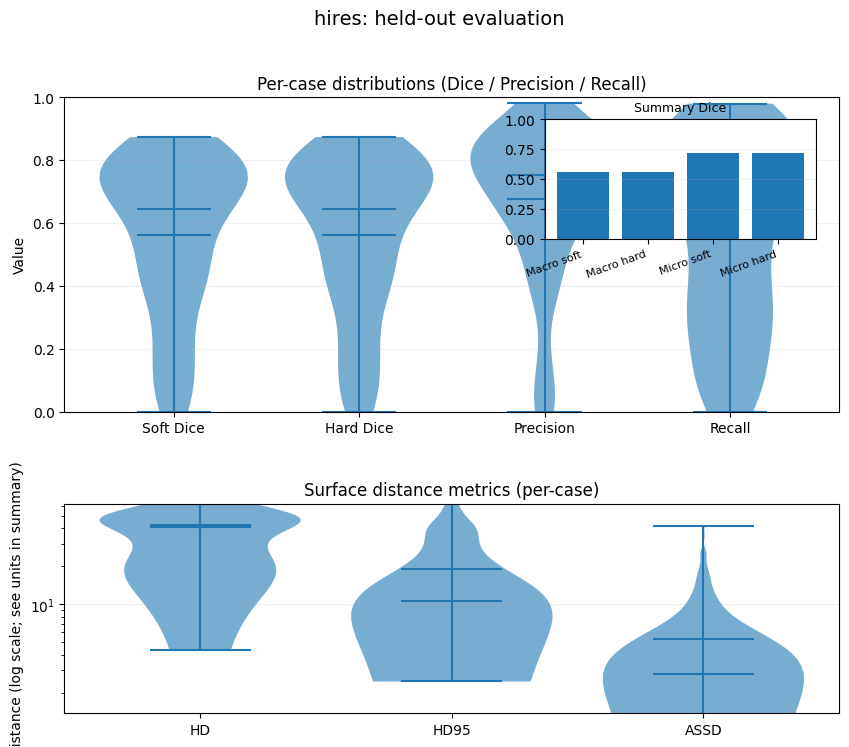

Composite figure: /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20260410_174944/test_eval/test_hires_composite_20260413_110932.png
Merged CSV with manifest -> /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20260410_174944/test_eval/test_hires_metrics_with_manifest_20260413_110932.csv
Wrote summary CSV -> /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20260410_174944/test_eval/test_hires_summary_stats.csv
Datasets ready for plotting: ['hires']
Rows: 138 | Saved per-case CSV: /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20260410_174944/test_eval/test_hires_metrics_20260413_110932.csv
Saved one-row summary CSV: /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20260410_174944/test_eval/test_hires_summary_stats.csv


In [5]:
# ===== Cell 3 (FINAL): RUN full evaluation on one dataset, compute summaries (no plots) =====
from pathlib import Path
import csv, json
import numpy as np
from typing import Dict, List, Any

# ---- small helpers (NaN-safe summaries) ----
def _dropna(a):
    a = np.asarray(a, float)
    return a[~np.isnan(a)]

def summarize_vector(x) -> Dict[str, float]:
    v = _dropna(np.array(x, float))
    if v.size == 0:
        return dict(n=0, mean=np.nan, median=np.nan, std=np.nan,
                    p25=np.nan, p75=np.nan, min=np.nan, max=np.nan, nan_count=len(x))
    return dict(
        n=int(v.size),
        mean=float(np.mean(v)),
        median=float(np.median(v)),
        std=float(np.std(v, ddof=1)) if v.size > 1 else 0.0,
        p25=float(np.percentile(v,25)),
        p75=float(np.percentile(v,75)),
        min=float(np.min(v)),
        max=float(np.max(v)),
        nan_count=int(len(x) - v.size),
    )

def summarize_dataset(rows: List[Dict[str, Any]]) -> Dict[str, Any]:
    soft = [r["soft_dice"] for r in rows]
    # detect the hard-dice column name we wrote in Cell 2
    hard_key = next((k for k in rows[0].keys() if k.startswith("hard_dice_at_")), "hard_dice_at_0.50")
    hard = [r[hard_key] for r in rows]
    prec = [r["precision"] for r in rows]
    rec  = [r["recall"]   for r in rows]
    hd   = [r["hd"]       for r in rows]
    hd95 = [r["hd95"]     for r in rows]
    assd = [r["assd"]     for r in rows]
    return {
        "soft": summarize_vector(soft),
        "hard": summarize_vector(hard),
        "prec": summarize_vector(prec),
        "rec":  summarize_vector(rec),
        "hd":   summarize_vector(hd),
        "hd95": summarize_vector(hd95),
        "assd": summarize_vector(assd),
    
    }

def write_summary_csv(summary_table: List[Dict[str, Any]], out_path: Path):
    if not summary_table:
        print("No summary to write."); return
    keys = sorted({k for row in summary_table for k in row.keys()})
    with open(out_path, "w", newline="") as f:
        wr = csv.DictWriter(f, fieldnames=keys)
        wr.writeheader(); wr.writerows(summary_table)
    print("Wrote summary CSV ->", out_path)

# -------- RUN THIS BLOCK (edit paths/tag/prefix only) --------
RUN_DIR   = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20260410_174944")
TEST_DIR  = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/A_A_Combined_Data/Processed_HiresLowres_Split_Data/test_hires")
TRAIN_MOD = Path("/home/rbielski/stroke_cleaned/stroke_segmentation_v1.2/stroke_seg_v1.2_train.py")
T1_DIR    = TEST_DIR / "t1"
MSK_DIR   = TEST_DIR / "masks"
MANIFEST  = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/A_A_Combined_Data/Processed_HiresLowres_Split_Data/test_hires.csv")

DATASET_TAG = "hires"         # <<< change per dataset (e.g., "lores", "thickslice")
SAVE_PREFIX = "test_hires"     # <<< change per dataset

# 1) Run the full evaluation over ALL images (model inference + metrics + CSV/JSON/PNG)
rows, summary, paths = run_eval_and_viz(
    RUN_DIR=RUN_DIR, TEST_DIR=TEST_DIR, TRAIN_MOD_PATH=TRAIN_MOD,
    T1_DIR=T1_DIR, MSK_DIR=MSK_DIR, MANIFEST_CSV=MANIFEST,
    TH=0.50, save_prefix=SAVE_PREFIX, dataset_tag=DATASET_TAG
)

# 2) Build the 'datasets' dict Cell 4 expects (from in-memory rows)
datasets: Dict[str, Dict[str, Any]] = {
    DATASET_TAG: {
        "rows": rows,                         # per-case metrics (list of dicts)
        "summary": summarize_dataset(rows),   # mean/median/std/etc per metric
        "source_paths": [paths["per_case_csv"]]
    }
}

# 3) Also write a tiny one-row summary CSV for this dataset (next to the per-case CSV)
summary_table = []
flat = {"dataset_tag": DATASET_TAG}
for metric, stats in datasets[DATASET_TAG]["summary"].items():
    for k, v in stats.items():
        flat[f"{metric}_{k}"] = v
summary_table.append(flat)
out_summary = Path(paths["per_case_csv"]).with_name(f"{SAVE_PREFIX}_summary_stats.csv")
write_summary_csv(summary_table, out_summary)

print("Datasets ready for plotting:", list(datasets.keys()))
print(f"Rows: {len(datasets[DATASET_TAG]['rows'])} | Saved per-case CSV: {paths['per_case_csv']}")
print(f"Saved one-row summary CSV: {out_summary}")


In [6]:
# === Pretty grouped violins (final tweaks) ===
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from pathlib import Path
from typing import Dict, Any, List

PALETTE       = ["#4C78A8"]      # add more colors if plotting multiple datasets
POINT_ALPHA   = 0.55
POINT_SIZE    = 10
VIOLIN_ALPHA  = 0.18             # extra transparent so dots show clearly
EDGE_ALPHA    = 0.35
ROBUST_PERC   = (5, 95)
JITTER_WIDTH  = 0.08
SEED          = 7
_rng = np.random.default_rng(SEED)

def _dropna(a): 
    a = np.asarray(a, float); 
    return a[~np.isnan(a)]

def _robust_limits_linear(arr, p=(5,95), min_span=1e-6):
    arr = _dropna(arr)
    if arr.size == 0: return (0.0, 1.0)
    lo, hi = np.percentile(arr, p[0]), np.percentile(arr, p[1])
    if hi - lo < min_span: hi = lo + min_span
    return float(lo), float(hi)

def _beeswarm_x(center: float, n: int, spread: float) -> np.ndarray:
    if n == 0: return np.array([])
    return center + _rng.normal(0.0, spread, size=n)

def _get_val(row: Dict[str, Any], key: str):
    if key == "soft": return row.get("soft", row.get("soft_dice"))
    if key == "hard":
        for k in row.keys():
            if k.startswith("hard_dice"): return row[k]
        return row.get("hard")
    if key == "prec": return row.get("prec", row.get("precision"))
    if key == "rec":  return row.get("rec",  row.get("recall"))
    return row.get(key)  # hd, hd95, assd

def pretty_violins_from_datasets(
    datasets: Dict[str, Dict[str, Any]],
    title: str = "Higher Resolution Images Test Set",
    legend_label: str = "Individual Image Segmentation",
    distance_units: str = "mm",
    save_path = None,
    show_legend = False
):
    if not datasets:
        print("No datasets to plot."); 
        return None
    

    tags = sorted(datasets.keys())

    def metric_arrays(std_key: str) -> List[np.ndarray]:
        return [ _dropna([_get_val(r, std_key) for r in datasets[tag]["rows"]]) for tag in tags ]

    # arrays
    soft, hard, prec, rec  = (metric_arrays(k) for k in ["soft","hard","prec","rec"])
    hd, hd95, assd         = (metric_arrays(k) for k in ["hd","hd95","assd"])

    plt.style.use("default")
    fig = plt.figure(figsize=(12, 8))
    gs  = GridSpec(2, 1, height_ratios=[3, 2], hspace=0.40)
    ax_top = fig.add_subplot(gs[0])
    ax_bot = fig.add_subplot(gs[1])

    def draw_grouped(ax, data_seq: List[List[np.ndarray]], base_labels: List[str],
                    ylabel=None, panel_title=None, is_distance=False):
        groups = len(data_seq)
        nd     = len(tags)
        base_x = np.arange(1, groups+1, dtype=float)
        width, step = 0.9, 0.9/(nd+1)

        # remove any leftover legend from previous runs
        leg = ax.get_legend()
        if leg is not None:
            leg.remove()

        all_vals = []
        for di, tag in enumerate(tags):
            color  = PALETTE[di % len(PALETTE)]
            offset = (di - (nd-1)/2) * step
            for gi in range(groups):
                vals = data_seq[gi][di]
                all_vals.append(vals)
                pos = base_x[gi] + offset
                parts = ax.violinplot([vals if vals.size else np.array([np.nan])],
                                    positions=[pos], widths=step*0.95,
                                    showmeans=True, showmedians=True)
                for b in parts.get('bodies', []):
                    b.set_facecolor(color)
                    b.set_edgecolor((0,0,0,EDGE_ALPHA))
                    b.set_alpha(VIOLIN_ALPHA)
                if 'cmeans' in parts:
                    parts['cmeans'].set_linewidth(1.6); parts['cmeans'].set_color((0,0,0,0.85))
                if 'cmedians' in parts:
                    parts['cmedians'].set_linewidth(1.6); parts['cmedians'].set_color((0,0,0,0.85))
                if vals.size:
                    xs = _beeswarm_x(pos, len(vals), JITTER_WIDTH)
                    ax.scatter(xs, vals, s=POINT_SIZE, alpha=POINT_ALPHA, color=color, edgecolor='none')

        ax.set_xticks(base_x)
        ax.set_xticklabels(base_labels)
        if ylabel: ax.set_ylabel(ylabel)
        if panel_title: ax.set_title(panel_title, pad=18)
        flat = np.concatenate([v for v in all_vals if v.size]) if any(v.size for v in all_vals) else np.array([])
        if flat.size:
            lo, hi = _robust_limits_linear(flat, p=ROBUST_PERC)
            if not is_distance:
                lo = max(0.0, lo); hi = min(1.0, max(0.9, hi))
            ax.set_ylim(lo, hi)
        ax.grid(True, axis='y', alpha=0.25)

        # only add legend if requested
        if show_legend:
            ax.plot([], [], marker='o', ls='', color=PALETTE[0], label=legend_label)
            ax.legend(loc="upper left", bbox_to_anchor=(1.23, 1.03), frameon=False)


    # Top (Dice/PR)
    draw_grouped(
        ax_top,
        data_seq=[soft, hard, prec, rec],
        base_labels=["Soft Dice", "Hard Dice", "Precision", "Recall"],
        ylabel="Value",
        panel_title="Per-case distributions (Dice / Precision / Recall)",
        is_distance=False
    )

    # Bottom (Distances) — linear + units
    draw_grouped(
        ax_bot,
        data_seq=[hd, hd95, assd],
        base_labels=["HD", "HD95", "ASSD"],
        ylabel=f"Distance ({distance_units})",
        panel_title="Surface distance metrics (per-case)",
        is_distance=True
    )

    # Figure title (exact text you asked for)
    fig.suptitle(title, y=0.99, fontsize=16)
    plt.tight_layout()

    # Save
    if save_path is None:
        any_row = next(iter(datasets[tags[0]]["rows"]), None)
        default_dir = Path(any_row["img_path"]).parent if any_row and any_row.get("img_path") else Path(".")
        save_path = default_dir / "pretty_violins_linear_final.png"
    fig.savefig(save_path, dpi=180, bbox_inches="tight")
    print("Saved figure ->", save_path)

    plt.show()
    return fig


Saved figure -> /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/A_A_Combined_Data/Processed_HiresLowres_Split_Data/test_hires/t1/pretty_violins_linear_final.png


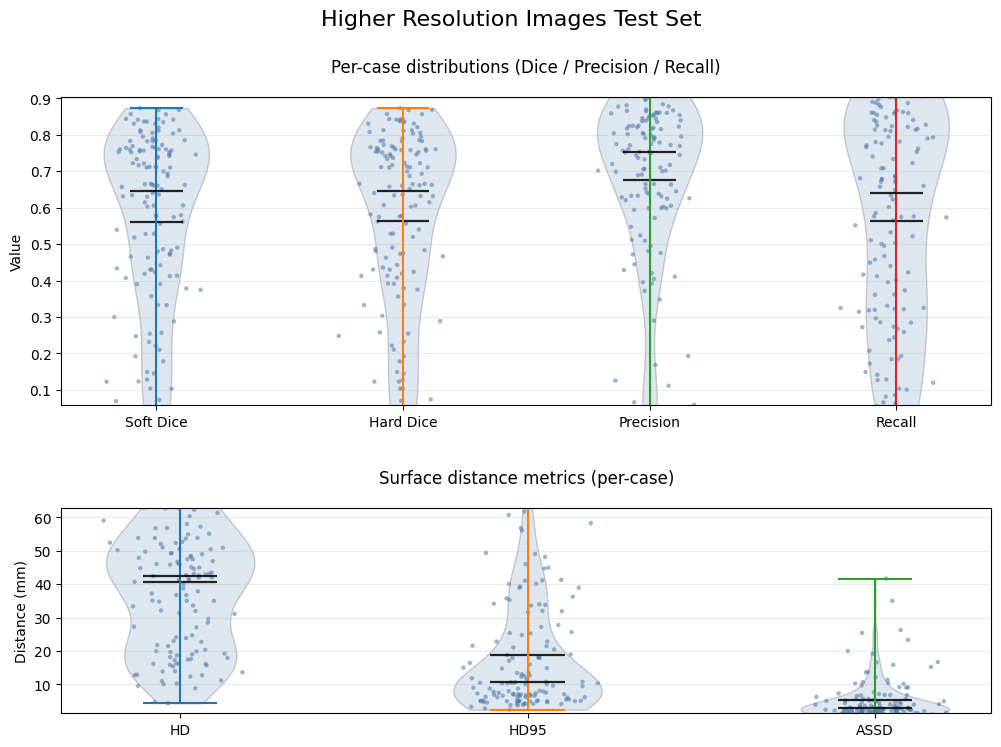

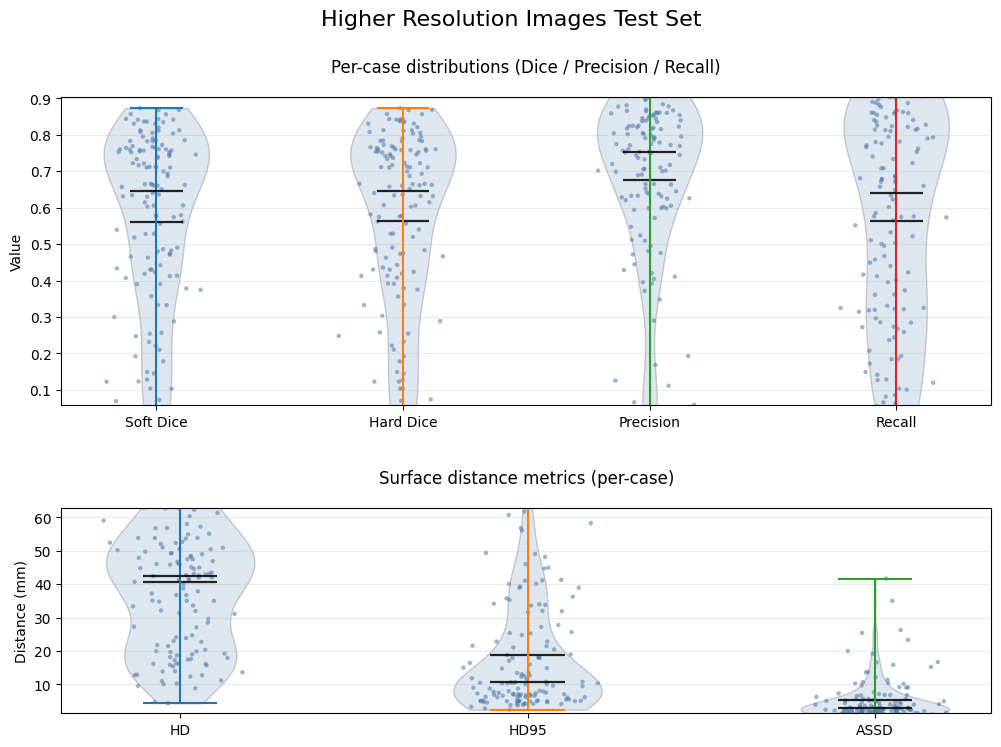

In [7]:
pretty_violins_from_datasets(
    datasets,
    title="Higher Resolution Images Test Set",
    distance_units="mm"   # change if you evaluated in voxels
)


# BELOW EVALUATES THE RESULTS ACROSS IMAGE QUALITY AND LESIONS SIZES> NEED TO REPLACE IN NEW NOTEBOOK WITH EVAL ACROSS ALL HELD OUT DATA +++++++++++++++++++++++++++++++++++++++++++++++++++

In [9]:
# === Robust join: handle eval CSV with either `case` or `key` ===
from pathlib import Path
import csv, re, math, time
import numpy as np
import nibabel as nib

# ---------- CONFIG ----------
RUN_DIR    = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20260410_174944")
TEST_EVAL  = RUN_DIR / "test_eval"
# Use the plain per-case eval if you have it; otherwise this also supports the merged one:
# Auto-find the latest plain eval CSV (test_metrics_*.csv, not _with_manifest_)
_eval_csvs = sorted([p for p in TEST_EVAL.glob("test_metrics_*.csv")
                     if "_with_manifest_" not in p.name and "_summary_" not in p.name])
assert _eval_csvs, f"No test_metrics_*.csv found in {TEST_EVAL}"
EVAL_CSV   = _eval_csvs[-1]  # most recent
print("Using eval CSV:", EVAL_CSV.name)
# If you only have the merged file, use that instead:

MANIFEST   = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/A_A_Combined_Data/Processed_HiresLowres_Split_Data/test_hires.csv")
# -------------------------------------------

def _norm_key(name: str) -> str:
    n = re.sub(r"\.nii(\.gz)?$", "", name or "")
    n = re.sub(r"_T1w", "", n)
    n = re.sub(r"_MNI_norm", "", n)
    n = re.sub(r"_lesion_mask(_MNI)?_clean", "", n)
    n = re.sub(r"_(soft|hard)$", "", n)
    return n

def _to_float(x):
    try: return float(x)
    except Exception: return float("nan")

def _to_int(x):
    try: return int(float(x))
    except Exception: return 0

# --- Load manifest keyed by `key` ---
manifest = {}
with open(MANIFEST, newline="") as f:
    for row in csv.DictReader(f):
        k = (row.get("key") or "").strip()
        if not k:
            # derive from t1_path/mask_path if key missing
            for src in (row.get("t1_path"), row.get("mask_path")):
                if src:
                    k = _norm_key(Path(src).name)
                    break
        if not k:
            continue
        manifest[k] = {
            "dataset": row.get("dataset", ""),
            "t1_path": row.get("t1_path", ""),
            "mask_path": row.get("mask_path", ""),
            "fwhm_mm": _to_float(row.get("fwhm_mm", "")),
            "hi_freq_energy": _to_float(row.get("hi_freq_energy", "")),
            "lap_var": _to_float(row.get("lap_var", "")),
            "score": _to_float(row.get("score", "")),
            "bin": row.get("bin", ""),
            "mask_voxels": _to_int(row.get("mask_voxels", "")),
            "mask_ml": _to_float(row.get("mask_ml", "")),
            "mask_voxels_clean": _to_int(row.get("mask_voxels_clean", "")),
            "mask_ml_clean": _to_float(row.get("mask_ml_clean", "")),
            "brain_frac": _to_float(row.get("brain_frac", "")),
            "vox_total": _to_int(row.get("vox_total", "")),
            "norm_img_nonzero": _to_int(row.get("norm_img_nonzero", "")),
            "brain_voxels": _to_int(row.get("brain_voxels", "")),
            "voxel_mm3": _to_float(row.get("voxel_mm3", "")),
        }

print("Manifest rows:", len(manifest))

# --- Load eval CSV; accept either `case` or `key` ---
with open(EVAL_CSV, newline="") as f:
    rd = csv.DictReader(f)
    cols = [c for c in (rd.fieldnames or []) if c]
    has_key  = "key"  in cols
    has_case = "case" in cols
    # Find hard dice col: "hard_dice" or "hard_dice_at_*"
    hard_col = None
    for c in cols:
        if c == "hard_dice" or c.startswith("hard_dice_at_"):
            hard_col = c; break
    if hard_col is None:
        hard_col = "hard_dice_at_0.50"  # best guess

    eval_rows = []
    for row in rd:
        if has_key:
            k = (row.get("key") or "").strip()
        elif has_case:
            k = _norm_key(row.get("case") or "")
        else:
            # last-ditch: try to infer from any present path-like column
            candidates = [row.get(x,"") for x in cols if "path" in x.lower()]
            k = ""
            for cand in candidates:
                if cand:
                    k = _norm_key(Path(cand).name); break

        if not k:
            continue
        eval_rows.append({
            "key": k,
            "soft_dice": _to_float(row.get("soft_dice", "")),
            "hard_dice": _to_float(row.get(hard_col, "")),
        })

print("Eval rows:", len(eval_rows))

# --- Recompute lesion size when manifest is missing/zero ---
def _recompute_size(mask_path: str, voxel_mm3: float):
    try:
        m = np.asanyarray(nib.load(mask_path).get_fdata())
        vox = int((m > 0).sum())
        ml  = float(vox * (voxel_mm3 if not math.isnan(voxel_mm3) and voxel_mm3 > 0 else 1.0) / 1000.0)
        return vox, ml
    except Exception:
        return 0, float("nan")

joined, missing, recomputed = [], 0, 0
for r in eval_rows:
    info = manifest.get(r["key"])
    if not info:
        missing += 1
        continue
    vox = info["mask_voxels_clean"] or info["mask_voxels"] or 0
    ml  = info["mask_ml_clean"] if not math.isnan(info["mask_ml_clean"]) else info["mask_ml"]
    if vox == 0:
        v2, m2 = _recompute_size(info["mask_path"], info["voxel_mm3"])
        vox, ml = v2, m2
        recomputed += 1
    joined.append({
        "key": r["key"],
        "soft_dice": r["soft_dice"],
        "hard_dice": r["hard_dice"],
        "voxels_clean": int(vox),
        "ml_clean": float(ml) if (ml is not None and not math.isnan(ml)) else float("nan"),
        "fwhm_mm": info["fwhm_mm"],
        "hi_freq_energy": info["hi_freq_energy"],
        "lap_var": info["lap_var"],
        "score": info["score"],
        "brain_frac": info["brain_frac"],
        "vox_total": info["vox_total"],
        "dataset": info["dataset"],
        "bin": info["bin"],
        "mask_path": info["mask_path"],
        "voxel_mm3": info["voxel_mm3"],
    })

print(f"Joined cases: {len(joined)} | Missing in manifest: {missing} | Recomputed sizes: {recomputed}")

# If joins still look wrong, show a few keys that failed:
if len(joined) == 0 and missing > 0:
    eval_keys = {r["key"] for r in eval_rows}
    man_keys  = set(manifest.keys())
    not_in_manifest = sorted(list(eval_keys - man_keys))[:10]
    print("Examples not in manifest:", not_in_manifest)

# --- Correlations & summaries (same as before) ---
def _col(name, dtype=np.float64):
    return np.array([row[name] for row in joined], dtype=dtype)

def nan_pearson(x, y):
    m = (~np.isnan(x)) & (~np.isnan(y))
    if m.sum() < 3: return float("nan")
    return float(np.corrcoef(x[m], y[m])[0,1])

if joined:
    soft = _col("soft_dice"); hard = _col("hard_dice"); vox = _col("voxels_clean")
    fwhm = _col("fwhm_mm"); hfe = _col("hi_freq_energy"); lapv = _col("lap_var")
    score = _col("score"); bfr = _col("brain_frac")
    log_vox = np.log10(np.where(vox > 0, vox, np.nan))

    print("\n=== Correlations (Pearson r) ===")
    print(f"r(soft_dice, log10(lesion_vox)) = {nan_pearson(soft, log_vox):.3f}")
    print(f"r(hard_dice, log10(lesion_vox)) = {nan_pearson(hard, log_vox):.3f}")
    print(f"r(soft_dice, fwhm_mm)           = {nan_pearson(soft, fwhm):.3f}")
    print(f"r(soft_dice, hi_freq_energy)    = {nan_pearson(soft, hfe):.3f}")
    print(f"r(soft_dice, lap_var)           = {nan_pearson(soft, lapv):.3f}")
    print(f"r(soft_dice, score)             = {nan_pearson(soft, score):.3f}")
    print(f"r(soft_dice, brain_frac)        = {nan_pearson(soft, bfr):.3f}")

    bins = [0, 2500, 10000, 30000, 60000, 10**9]
    labels = ["[0,2.5k)", "[2.5k,10k)", "[10k,30k)", "[30k,60k)", "[60k,+inf)"]
    print("\n=== Size-bin summary (voxels_clean) ===")
    for i in range(len(bins)-1):
        lo, hi = bins[i], bins[i+1]
        m = (vox >= lo) & (vox < hi)
        n = int(m.sum())
        ms = float(np.nanmean(soft[m])) if n > 0 else float("nan")
        mh = float(np.nanmean(hard[m])) if n > 0 else float("nan")
        print(f"{labels[i]:>12} | n={n:3d} | mean soft={ms:.4f} | mean hard={mh:.4f}")

    # Save merged CSV
    out_dir = TEST_EVAL; out_dir.mkdir(parents=True, exist_ok=True)
    ts = time.strftime("%Y%m%d_%H%M%S")
    out_path = out_dir / f"test_metrics_with_manifest_FIXED_{ts}.csv"
    with open(out_path, "w", newline="") as f:
        wr = csv.DictWriter(f, fieldnames=list(joined[0].keys()))
        wr.writeheader(); wr.writerows(joined)
    print("\nSaved merged per-case CSV ->", out_path)


Using eval CSV: test_metrics_20260413_105632.csv
Manifest rows: 138
Eval rows: 138
Joined cases: 138 | Missing in manifest: 0 | Recomputed sizes: 138

=== Correlations (Pearson r) ===
r(soft_dice, log10(lesion_vox)) = 0.553
r(hard_dice, log10(lesion_vox)) = 0.552
r(soft_dice, fwhm_mm)           = nan
r(soft_dice, hi_freq_energy)    = -0.140
r(soft_dice, lap_var)           = 0.317
r(soft_dice, score)             = 0.091
r(soft_dice, brain_frac)        = nan

=== Size-bin summary (voxels_clean) ===
    [0,2.5k) | n= 27 | mean soft=0.3257 | mean hard=0.3262
  [2.5k,10k) | n= 20 | mean soft=0.4991 | mean hard=0.4996
   [10k,30k) | n= 32 | mean soft=0.5456 | mean hard=0.5461
   [30k,60k) | n= 35 | mean soft=0.6481 | mean hard=0.6483
  [60k,+inf) | n= 24 | mean soft=0.7761 | mean hard=0.7762

Saved merged per-case CSV -> /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20260410_174944/test_eval/test_metrics_with_manifest_FIXED_20260413_112415.csv


/home/rbielski/.local/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/rbielski/.local/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [12]:
# === Plot + partial correlations + top/bottom cases ===
from pathlib import Path
import csv, time, math
import numpy as np
import matplotlib.pyplot as plt

RUN_DIR   = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20260410_174944")
# Auto-find the latest with_manifest CSV (written by cell 9)
_manifest_csvs = sorted(
    (RUN_DIR / "test_eval").glob("test_metrics_with_manifest_FIXED_*.csv"),
    key=lambda p: p.stat().st_mtime)
assert _manifest_csvs, "Run cell 9 first to generate the manifest-joined CSV"
CSV_PATH  = _manifest_csvs[-1]
print("Using:", CSV_PATH.name)
OUT_DIR   = RUN_DIR / "test_eval" / "figs"; OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---- load
rows = []
with open(CSV_PATH, newline="") as f:
    rd = csv.DictReader(f)
    for r in rd:
        rows.append(r)

def col(name, cast=float):
    out = []
    for r in rows:
        v = r.get(name, "")
        try: out.append(cast(v))
        except: out.append(float("nan"))
    return np.array(out, dtype=float)

soft  = col("soft_dice")
hard  = col("hard_dice")
vox   = col("voxels_clean", int).astype(float)
hfe   = col("hi_freq_energy")
lapv  = col("lap_var")
score = col("score")
bfr   = col("brain_frac")
logv  = np.log10(np.where(vox>0, vox, np.nan))

def nan_corr(x, y):
    m = (~np.isnan(x)) & (~np.isnan(y))
    if m.sum() < 3: return np.nan
    return float(np.corrcoef(x[m], y[m])[0,1])

# partial corr(soft, metric | logv) via linear residuals
def partial_corr(soft, metric, control):
    m = (~np.isnan(soft)) & (~np.isnan(metric)) & (~np.isnan(control))
    if m.sum() < 5: return np.nan
    s, z, c = soft[m], metric[m], control[m]
    # regress out control: residual = x - proj(x|c)
    def resid(x, c):
        A = np.vstack([c, np.ones_like(c)]).T
        beta, *_ = np.linalg.lstsq(A, x, rcond=None)
        return x - A @ beta
    rs = resid(s, c); rz = resid(z, c)
    return nan_corr(rs, rz)

pcorr_hfe  = partial_corr(soft, hfe, logv)
pcorr_lapv = partial_corr(soft, lapv, logv)
pcorr_score= partial_corr(soft, score, logv)

print("Partial r (soft, hfe | log size)  :", f"{pcorr_hfe:.3f}")
print("Partial r (soft, lapv | log size):", f"{pcorr_lapv:.3f}")
print("Partial r (soft, score | log size):", f"{pcorr_score:.3f}")

# ---- scatter helpers
def scatter(x, y, xlabel, ylabel, fname):
    m = (~np.isnan(x)) & (~np.isnan(y))
    xs, ys = x[m], y[m]
    plt.figure(figsize=(5.2,4.0))
    plt.scatter(xs, ys, s=14, alpha=0.6)
    # least-squares line
    if xs.size >= 2:
        A = np.vstack([xs, np.ones_like(xs)]).T
        b, a = np.linalg.lstsq(A, ys, rcond=None)[0]
        xx = np.linspace(xs.min(), xs.max(), 100)
        plt.plot(xx, a + b*xx)
        r = np.corrcoef(xs, ys)[0,1]
        plt.title(f"r = {r:.3f}")
    plt.xlabel(xlabel); plt.ylabel(ylabel); plt.tight_layout()
    p = OUT_DIR / fname
    plt.savefig(p, dpi=150); plt.close()
    print("Saved", p)

scatter(logv, soft, "log10(lesion vox)", "soft Dice", "scatter_soft_vs_logvox.png")
scatter(hfe,  soft, "hi_freq_energy",   "soft Dice", "scatter_soft_vs_hfe.png")
scatter(lapv, soft, "lap_var",          "soft Dice", "scatter_soft_vs_lapvar.png")
scatter(score,soft, "score",            "soft Dice", "scatter_soft_vs_score.png")

# ---- top/bottom by soft Dice (with size)
keys  = [r["key"] for r in rows]
order = np.argsort(soft)  # ascending
bottom_idx = order[:10]
top_idx    = order[-10:][::-1]

def show_list(ix, title):
    print("\n"+title)
    for i in ix:
        print(f"  {keys[i]:40s} | soft={soft[i]:.4f} | vox={int(vox[i])}")

show_list(bottom_idx, "Bottom 10 by soft Dice")
show_list(top_idx,    "Top 10 by soft Dice")


Using: test_metrics_with_manifest_FIXED_20260413_112415.csv
Partial r (soft, hfe | log size)  : -0.027
Partial r (soft, lapv | log size): 0.089
Partial r (soft, score | log size): 0.032
Saved /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20260410_174944/test_eval/figs/scatter_soft_vs_logvox.png
Saved /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20260410_174944/test_eval/figs/scatter_soft_vs_hfe.png
Saved /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20260410_174944/test_eval/figs/scatter_soft_vs_lapvar.png
Saved /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20260410_174944/test_eval/figs/scatter_soft_vs_score.png

Bottom 10 by soft Dice
  sub-r038s065_ses-1                       | soft=0.0000 | vox=1577
  sub-r038s023_ses-1                       | soft=0.0000 | vox=1532
  sub-r038s089_ses-1                       | soft=0.0000 | vox=1592
  sub-r038s020_ses-1                      

In [ ]:
# === Write a compact Markdown report from the latest NON-EMPTY joined CSV ===
from pathlib import Path
from datetime import datetime
import csv, math, numpy as np, os

# Point at your v3 run folder
RUN_DIR  = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20260410_174944")
EVAL_DIR = RUN_DIR / "test_eval"
FIG_DIR  = EVAL_DIR / "figs"
EVAL_DIR.mkdir(parents=True, exist_ok=True)

def csv_row_count(p: Path) -> int:
    try:
        with open(p, newline="") as f:
            r = csv.reader(f)
            header = next(r, None)
            if header is None:
                return 0
            n = 0
            for _ in r:
                n += 1
            return n
    except Exception:
        return 0

# Prefer files containing "with_manifest"; pick the newest with >=1 data row
candidates = sorted(EVAL_DIR.glob("test_metrics_with_manifest*.csv"), key=lambda p: p.stat().st_mtime)
candidates = candidates[::-1]  # newest first

CSV_JOIN = None
for p in candidates:
    if csv_row_count(p) > 0:
        CSV_JOIN = p
        break

if CSV_JOIN is None:
    # Show diagnostic listing and stop early with a helpful message
    print("No non-empty 'with_manifest' CSVs found. Here are candidates with row counts:")
    for p in candidates[::-1]:
        print(f"- {p.name}  | rows={csv_row_count(p)}  | mtime={datetime.fromtimestamp(p.stat().st_mtime)}")
    raise SystemExit(0)

print("Using eval CSV:", CSV_JOIN)

# --- load rows ---
rows = []
with open(CSV_JOIN, newline="") as f:
    rd = csv.DictReader(f)
    for r in rd:
        rows.append(r)
if not rows:
    raise RuntimeError("CSV has no data rows (unexpected after the non-empty check).")

# --- pull numeric columns safely ---
def col(name, cast=float):
    arr = []
    for r in rows:
        v = r.get(name, "")
        try:
            arr.append(cast(v))
        except Exception:
            arr.append(float("nan"))
    return np.array(arr, dtype=float)

def pick(*names):
    """Return first available column among names."""
    for nm in names:
        if nm in rows[0]:
            return nm
    return names[-1]

soft_col = pick("soft_dice")
hard_col = pick("hard_dice", "hard_dice_at_0.50", "hard_dice_at_{:.2f}".format(0.50))
vox_col  = pick("voxels_clean", "lesion_voxels", "mask_voxels_clean")

soft  = col(soft_col)
hard  = col(hard_col)
vox   = col(vox_col, float)
hfe   = col("hi_freq_energy")
lapv  = col("lap_var")
score = col("score")

# Ensure positive sizes for log
logv  = np.log10(np.where(vox > 0, vox, np.nan))

# --- helpers ---
def nanmean(x): 
    m = ~np.isnan(x)
    return float(np.mean(x[m])) if m.any() else float("nan")

def nan_corr(x, y):
    m = (~np.isnan(x)) & (~np.isnan(y))
    if m.sum() < 3: return float("nan")
    return float(np.corrcoef(x[m], y[m])[0,1])

def partial_corr(y, x, control):
    m = (~np.isnan(y)) & (~np.isnan(x)) & (~np.isnan(control))
    if m.sum() < 5: return float("nan")
    y, x, c = y[m], x[m], control[m]
    A = np.vstack([c, np.ones_like(c)]).T
    by, *_ = np.linalg.lstsq(A, y, rcond=None)
    bx, *_ = np.linalg.lstsq(A, x, rcond=None)
    ry = y - A @ by
    rx = x - A @ bx
    return nan_corr(ry, rx)

# --- summary stats ---
macro_soft = nanmean(soft)
macro_hard = nanmean(hard)

r_size     = nan_corr(soft, logv)
r_hfe      = nan_corr(soft, hfe)
r_lapv     = nan_corr(soft, lapv)
r_score    = nan_corr(soft, score)

# partials controlling for lesion size
pr_hfe     = partial_corr(soft, hfe, logv)
pr_lapv    = partial_corr(soft, lapv, logv)
pr_score   = partial_corr(soft, score, logv)

# size-bin summary
bins   = [0, 2500, 10000, 30000, 60000, 10**9]
labels = ["[0,2.5k)", "[2.5k,10k)", "[10k,30k)", "[30k,60k)", "[60k,+inf)"]
bin_lines = []
for i in range(len(bins)-1):
    lo, hi = bins[i], bins[i+1]
    m = (vox >= lo) & (vox < hi)
    n = int(np.sum(m))
    bin_soft = nanmean(soft[m]) if n>0 else float("nan")
    bin_hard = nanmean(hard[m]) if n>0 else float("nan")
    bin_lines.append(f"- **{labels[i]}**: n={n}, mean soft={bin_soft:.4f}, mean hard={bin_hard:.4f}")

# cohort split by leading letter in key (if present)
keys = [r.get("key","") for r in rows]
lead = np.array([(k[0].lower() if k else "") for k in keys])
summary_lines = []
for tag in sorted(set(lead) - {""}):
    m = (lead == tag)
    summary_lines.append(f"- **{tag}** | n={int(np.sum(m))} | mean soft={nanmean(soft[m]):.4f}")

# --- compose Markdown ---
ts = datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_MD = EVAL_DIR / f"evaluation_summary_{ts}.md"

md = []
md.append("# Held-out Evaluation Summary")
md.append("")
md.append(f"**Run:** `{RUN_DIR.name}`")
md.append(f"**Per-case macro Dice (soft):** {macro_soft:.4f}")
md.append(f"**Per-case macro Dice (hard @0.50):** {macro_hard:.4f}")
md.append("")
md.append("## Correlations")
md.append(f"- r(soft Dice, log10 lesion size): **{r_size:.3f}**")
md.append(f"- r(soft Dice, hi_freq_energy): **{r_hfe:.3f}**  | partial (| size): **{pr_hfe:.3f}**")
md.append(f"- r(soft Dice, lap_var): **{r_lapv:.3f}**       | partial (| size): **{pr_lapv:.3f}**")
md.append(f"- r(soft Dice, score): **{r_score:.3f}**        | partial (| size): **{pr_score:.3f}**")
md.append("")
md.append("## Mean Dice by lesion-size bin")
md.extend(bin_lines)
if summary_lines:
    md.append("")
    md.append("## Cohort summary (by key prefix)")
    md.extend(summary_lines)

# Optionally embed figures if they exist
figs = [
    "scatter_soft_vs_logvox.png",
    "scatter_soft_vs_hfe.png",
    "scatter_soft_vs_lapvar.png",
    "scatter_soft_vs_score.png",
]
existing_figs = [p for p in figs if (FIG_DIR / p).exists()]
if existing_figs:
    md.append("")
    md.append("## Figures")
    for p in existing_figs:
        md.append(f"- ![{p}]({FIG_DIR.name}/{p})")

md.append("")
md.append("## Sources")
md.append(f"- Joined per-case CSV: `{CSV_JOIN}`")
md.append(f"- Figures dir (if generated): `{FIG_DIR}`")

OUT_MD.write_text("\n".join(md))
print("Wrote:", OUT_MD)


Using eval CSV: /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20260410_174944/test_eval/test_metrics_with_manifest_FIXED_20260413_112415.csv
Wrote: /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20260410_174944/test_eval/evaluation_summary_20260413_112905.md


: 